## Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from pathlib import Path
import sys
import os
import mlflow
import dagshub

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

PARENT_DIRECTORY = Path.cwd().parent
#print(Path.cwd())
#print(PARENT_DIRECTORY)
sys.path.append(str(PARENT_DIRECTORY))
# sys.path.append(f'{PARENT_DIRECTORY}/scripts')
#print(sys.path)

from scripts.eda import EDA

sns.set_theme(style= 'whitegrid', context= 'notebook', palette= 'deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUTA_YAML = '../params.yaml'
with open(RUTA_YAML, 'r') as f:
    params = yaml.safe_load(f)

In [3]:
FEATURES = params['features']
MLFLOW = params['mlflow']
CONFIG = params['config']

## Features
FEAT_NUMERICALS = FEATURES['numeric']
FEAT_CATEGORICALS = FEATURES['categorical']
TARGET = FEATURES['target']
PERIOD = FEATURES['period']

## Train - Test - OOT
DATA_RAW = pd.read_csv(
    CONFIG['data_raw'],
    parse_dates= ['period']
)   
SPLIT_RESUMEN = pd.read_csv('../artifacts/eda/tables/split_resumen.csv')
df_train = DATA_RAW.loc[DATA_RAW['period'] < '2025-01-01'].sort_values(by= ['customer_id', 'period'], ascending= [True, True])
df_test = DATA_RAW.loc[(DATA_RAW['period'] > '2024-12-01') & (DATA_RAW['period'] < '2026-01-01')]
df_oot = DATA_RAW.loc[(DATA_RAW['period'] > '2025-12-01') & (DATA_RAW['period'] < '2027-01-01')]

### Información de registros mensuales por cliente en Train

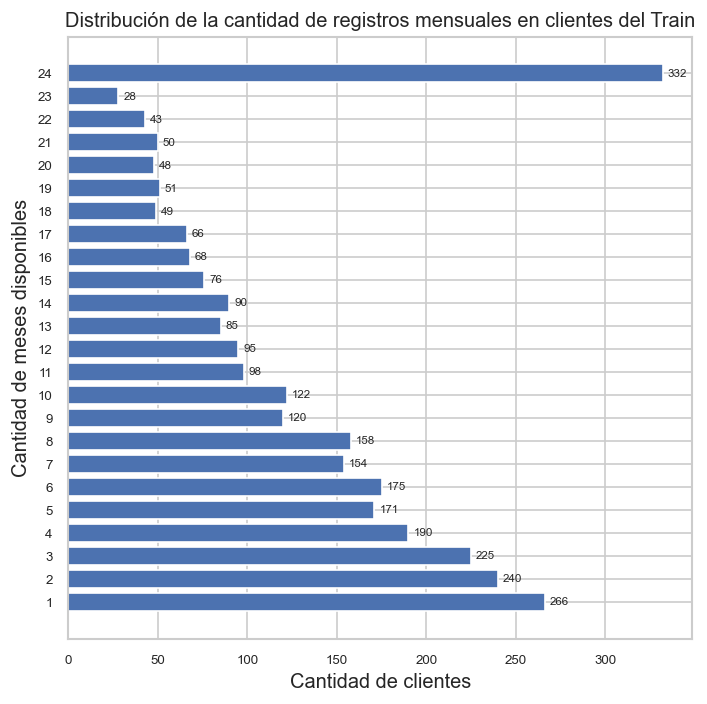

In [4]:
history = df_train.groupby('customer_id').size().value_counts().sort_index()

fig, ax = plt.subplots(1,1, figsize = (6, 6))
bar_label = ax.barh(
    history.index[::-1],
    history.values[::-1],
)
ax.bar_label(bar_label, fmt= '%d', padding= 3, fontsize =7)
ax.set_title('Distribución de la cantidad de registros mensuales en clientes del Train')
ax.set_ylabel('Cantidad de meses disponibles')
ax.set_xlabel('Cantidad de clientes')
ax.tick_params(axis= 'x', labelsize = 8)
ax.tick_params(axis= 'y', labelsize = 8)
ax.set_yticks(history.index[::-1]) 
plt.tight_layout()
plt.show()

## Features Temporales

### Lags

In [5]:
FEATS_W_LAG = [
    'usage_minutes',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'marketing_emails_opened',
    'active_days_last_month'
]

LAGS = [1, 3, 6, 12]

for feat in FEATS_W_LAG:
    for lag in LAGS:
        tmp_feat = f'{feat}_lag_{lag}'
        df_train[tmp_feat] = df_train.groupby('customer_id')[feat].shift(lag)

### Ratios Temporales

- mean_3m
- mean_12
- max_12m
- min_12
- std_3m
- std_12m


Comportamiento reciente vs antiguo

In [10]:
df_train.columns

Index(['customer_id', 'period', 'tenure_months', 'age', 'region',
       'contract_type', 'monthly_charges', 'usage_minutes', 'support_calls',
       'complaints_last_3m',
       ...
       'marketing_emails_opened_lag_1_range_6',
       'marketing_emails_opened_lag_1_max_12',
       'marketing_emails_opened_lag_1_min_12',
       'marketing_emails_opened_lag_1_range_12',
       'active_days_last_month_lag_1_max_6',
       'active_days_last_month_lag_1_min_6',
       'active_days_last_month_lag_1_range_6',
       'active_days_last_month_lag_1_max_12',
       'active_days_last_month_lag_1_min_12',
       'active_days_last_month_lag_1_range_12'],
      dtype='str', length=135)

In [7]:
df_train

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,...,late_payments_lag_6,late_payments_lag_12,marketing_emails_opened_lag_1,marketing_emails_opened_lag_3,marketing_emails_opened_lag_6,marketing_emails_opened_lag_12,active_days_last_month_lag_1,active_days_last_month_lag_3,active_days_last_month_lag_6,active_days_last_month_lag_12
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,...,NaN,NaN,0.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,...,NaN,NaN,1.0,NaN,NaN,NaN,21.0,NaN,NaN,NaN
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,...,NaN,NaN,0.0,0.0,NaN,NaN,23.0,19.0,NaN,NaN
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,...,NaN,NaN,3.0,1.0,NaN,NaN,29.0,21.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33124,C3000,2023-09-01,21,35,South,Monthly,81.26,392.43,0,0,...,0.0,NaN,3.0,1.0,1.0,NaN,26.0,25.0,20.0,NaN
33125,C3000,2023-10-01,22,35,South,Monthly,81.26,348.35,1,0,...,0.0,NaN,3.0,4.0,0.0,NaN,31.0,24.0,23.0,NaN
33126,C3000,2023-11-01,23,35,South,Monthly,81.26,497.04,0,0,...,1.0,NaN,2.0,3.0,3.0,NaN,21.0,26.0,17.0,NaN
33127,C3000,2023-12-01,24,35,South,Monthly,81.26,402.77,0,0,...,0.0,NaN,2.0,3.0,1.0,NaN,15.0,31.0,25.0,NaN


In [8]:
## lag 1
FEAT_LAG_1 = [d+"_lag_1" for d in FEATS_W_LAG]
## Separar los otros lag
FEAT_LAG_3 = [d+"_lag_3" for d in FEATS_W_LAG]
FEAT_LAG_6 = [d+"_lag_6" for d in FEATS_W_LAG]
FEAT_LAG_12 = [d+"_lag_12" for d in FEATS_W_LAG]

# Solo para el lag_1
## mean_3m & mean_12m

exclude = FEAT_NUMERICALS+FEAT_CATEGORICALS+['customer_id']+[PERIOD]+[TARGET]+FEAT_LAG_3+FEAT_LAG_6+FEAT_LAG_12
WINDOWS = [3, 6, 12]
FEATS_OPERATIONS = [d for d in (df_train.columns.to_list()) if d not in exclude]

## mean_3m & mean_6 & mean_12m

new_features = {}

grouped = df_train.groupby('customer_id')

for feat in FEATS_OPERATIONS:
    g = grouped[feat]

    for windows in WINDOWS:
        var_tmp = f'{feat}_mean_{windows}'
        new_features[f'{feat}_mean_{windows}'] = (
        g
        .transform(
            lambda x: x.rolling(window= windows, min_periods= 1).mean()
        ))

## std_3m & std_6m & std_12m
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in WINDOWS:
        var_tmp = f'{feat}_std_{windows}'
        new_features[f'{feat}_std_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods= 1).std()
            )
        ) 

## sum_3m & sum_6m & sum_12
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in WINDOWS:
        var_tmp = f'{feat}_sum_{windows}'
        new_features[f'{feat}_sum_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods= 1).sum()
            )            
        )


## Diferencias
for feat in FEATS_OPERATIONS:
    var_tmp = f'{feat}_diff_1'
    new_features[f'{feat}_diff'] = (
        df_train.groupby('customer_id')[feat].diff()
        )


## Rangos (Max - Min)
for feat in FEATS_OPERATIONS:
    g = grouped[feat]
    for windows in [6, 12]:
        var_tmp_max = f'{feat}_max_{windows}'
        var_tmp_min = f'{feat}_min_{windows}'
        var_tmp_range = f'{feat}_range_{windows}'
        new_features[f'{feat}_max_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).max()
            )
        )
        new_features[f'{feat}_min_{windows}'] = (
            g
            .transform(
                lambda x: x.rolling(window= windows, min_periods = 1).min()
            )
        )
        new_features[f'{feat}_range_{windows}'] = new_features[f'{feat}_max_{windows}'] - new_features[f'{feat}_min_{windows}']

df_new_features = pd.DataFrame(new_features, index = df_train.index)
df_train = pd.concat([df_train, df_new_features], axis = 1)
df_train = df_train.copy()

In [9]:
df_train

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,...,marketing_emails_opened_lag_1_range_6,marketing_emails_opened_lag_1_max_12,marketing_emails_opened_lag_1_min_12,marketing_emails_opened_lag_1_range_12,active_days_last_month_lag_1_max_6,active_days_last_month_lag_1_min_6,active_days_last_month_lag_1_range_6,active_days_last_month_lag_1_max_12,active_days_last_month_lag_1_min_12,active_days_last_month_lag_1_range_12
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,...,0.0,0.0,0.0,0.0,19.0,19.0,0.0,19.0,19.0,0.0
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,...,1.0,1.0,0.0,1.0,21.0,19.0,2.0,21.0,19.0,2.0
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,...,1.0,1.0,0.0,1.0,23.0,19.0,4.0,23.0,19.0,4.0
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,...,3.0,3.0,0.0,3.0,29.0,19.0,10.0,29.0,19.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33124,C3000,2023-09-01,21,35,South,Monthly,81.26,392.43,0,0,...,4.0,4.0,0.0,4.0,26.0,17.0,9.0,26.0,17.0,9.0
33125,C3000,2023-10-01,22,35,South,Monthly,81.26,348.35,1,0,...,4.0,4.0,0.0,4.0,31.0,17.0,14.0,31.0,17.0,14.0
33126,C3000,2023-11-01,23,35,South,Monthly,81.26,497.04,0,0,...,3.0,4.0,0.0,4.0,31.0,17.0,14.0,31.0,17.0,14.0
33127,C3000,2023-12-01,24,35,South,Monthly,81.26,402.77,0,0,...,3.0,4.0,0.0,4.0,31.0,15.0,16.0,31.0,15.0,16.0


In [ ]:
FEATS_W_LAG

['usage_minutes',
 'support_calls',
 'complaints_last_3m',
 'late_payments',
 'marketing_emails_opened',
 'active_days_last_month']

In [ ]:
df_train.head()

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,...,late_payments_lag_6,late_payments_lag_12,marketing_emails_opened_lag_1,marketing_emails_opened_lag_3,marketing_emails_opened_lag_6,marketing_emails_opened_lag_12,active_days_last_month_lag_1,active_days_last_month_lag_3,active_days_last_month_lag_6,active_days_last_month_lag_12
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,...,NaN,NaN,0.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,...,NaN,NaN,1.0,NaN,NaN,NaN,21.0,NaN,NaN,NaN
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,...,NaN,NaN,0.0,0.0,NaN,NaN,23.0,19.0,NaN,NaN
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,...,NaN,NaN,3.0,1.0,NaN,NaN,29.0,21.0,NaN,NaN


In [ ]:
## Features de recencia & frecuencia & acumulación
FEATS_RECENCIA_MAYOR_CERO = ['support_calls_lag_1', 'late_payments_lag_1', 'marketing_emails_opened_lag_1']
FEATS_RECENCIA_CONDICION = ['usage_minutes_lag_1', 'active_days_last_month_lag_1']

## Creando la feature de recencia

df_train["month_idx"] = (
    df_train["period"].dt.year * 12
    + df_train["period"].dt.month
)
new_features = {}

for feat in FEATS_RECENCIA_MAYOR_CERO:
    var_tmp = f'{feat}_lag_1_recencia'
    new_features[f'{feat}_boolean'] = df_train[feat] > 0
    
    # Creando índice mensual continuo

    new_features[f'{feat}_condicion'] = np.where(new_features[f'{feat}_boolean'], df_train['month_idx'], np.nan)
    new_features[f'{feat}_recencia'] = df_train['month_idx'] - ( pd.Series(new_features[f'{feat}_condicion'], index= df_train.index).groupby(df_train['customer_id']).ffill() )

    # Frecuencia & Acumulación / Severidad
    for windows in [6, 12]:

        new_features[f'{feat}_frec_{windows}'] = df_train.groupby('customer_id')[f'{feat}_boolean'].transform(
            lambda x: x.rolling(window= windows, min_periods= 1).sum()
        )

        # acumulación en un período de tiempo
        new_features[f'{feat}_sum_{windows}'] = (
            df_train.groupby('customer_id')[feat].transform(
                lambda x: x.rolling(window= windows, min_periods= 1).sum()
            )
        )

        ## acumulación histórica
        new_features[f'{feat}_cumsum'] = (
            df_train.groupby('customer_id')[feat].cumsum()
        )

## Feature recencia de usage_minutes
df_train['usage_min_evento'] = df_train[FEATS_RECENCIA_CONDICION[0]] < 233
df_train['usage_severity'] = np.maximum(0, 233 - df_train['usage_minutes_lag_1'])
df_train['usage_min_condicion']= np.where(df_train['usage_min_evento'], df_train['month_idx'], np.nan)
df_train['usage_min_lag_1_recencia'] = df_train['month_idx'] - (df_train.groupby('customer_id')['usage_min_condicion'].ffill())
df_train['usage_min_lag_1_frecuencia_6m'] = (
    df_train.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_train['usage_min_lag_1_frecuencia_12m'] = (
    df_train.groupby('customer_id')['usage_min_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)

df_train['usage_severity_sum_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_train['usage_severity_mean_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_train['usage_severity_std_3m'] = df_train.groupby('customer_id')['usage_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)

## Feature recencia de active_days_last_month_lag_1
df_train['active_days_last_month_evento'] = df_train[FEATS_RECENCIA_CONDICION[1]] < 23
df_train['active_days_last_month_condicion']= np.where(df_train['active_days_last_month_evento'], df_train['month_idx'], np.nan)
df_train['active_days_last_month_lag_1_recencia'] = df_train['month_idx'] - (df_train.groupby('customer_id')['active_days_last_month_condicion'].ffill())
df_train['active_days_last_month_severity'] = np.maximum(0, 23 - df_train['active_days_last_month_lag_1'])
df_train['active_days_last_month_freq_6m'] = (
    df_train.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 6, min_periods= 1).sum()
    )
)
df_train['active_days_last_month_freq_12m'] = (
    df_train.groupby('customer_id')['active_days_last_month_evento'].transform(
        lambda x: x.rolling(window= 12, min_periods= 1).sum()
    )
)
df_train['active_days_last_month_severity_sum_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).sum()
)
df_train['active_days_last_month_severity_mean_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).mean()
)
df_train['active_days_last_month_severity_std_3m'] = df_train.groupby('customer_id')['active_days_last_month_severity'].transform(
    lambda x: x.rolling(window= 3, min_periods= 1).std()
)



In [ ]:
## Creación de Feature Cambios porcentuales
# pct_change

df_train['usage_minutes_lag_1_pct_change'] = (
    df_train.groupby('customer_id')['usage_minutes_lag_1'].pct_change()
)

## Creación de Feature de Tendencia
# usage_mean_3m
df_train['usage_minutes_lag_1_trend_nom'] = (
    df_train['usage_minutes_lag_1_mean_3m'] - df_train['usage_minutes_lag_1_mean_12m'] 
)

# usage_ratio 
## ambos capturan bien la tendencia

eps = 1e-5
df_train['usage_minutes_lag_1_trend_var'] = (
    (df_train['usage_minutes_lag_1_mean_3m'] / (df_train['usage_minutes_lag_1_mean_12m']+eps)) 
)

## Creación de Feature de consistencia
# std/mean
df_train['usage_minutes_lag_1_consistencia'] = (
    (df_train['usage_minutes_lag_1_mean_6m'] / df_train['usage_minutes_lag_1_std_6m'])
)

## Creación de Features Calendario
df_train['month_regular'] = df_train['period'].dt.month
df_train['month_sin'] = np.sin((2 * np.pi * df_train['month_regular'])/12)
df_train['month_cos'] = np.cos((2 * np.pi * df_train['month_regular'])/12)

In [13]:
FEATS_RECENCIA_CONDICION[0]

'usage_minutes_lag_1'

In [17]:
FEATS_RECENCIA_CONDICION = ['usage_minutes_lag_1', 'active_days_last_month_lag_1']


evento_usage_min = np.where(df_train[FEATS_RECENCIA_CONDICION[0]], df_train[FEATS_RECENCIA_CONDICION[0]] < 233, np.nan)
evento_usage_min


array([0., 0., 0., ..., 0., 0., 0.], shape=(30080,))

In [14]:
df_train.loc[df_train['customer_id'] == 'C3000']

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,...,active_days_last_month_lag_3,active_days_last_month_lag_6,active_days_last_month_lag_12,evento_boolean,period_month,condition,support_calls_lag_1_recencia,late_payments_lag_1_recencia,marketing_emails_opened_lag_1_recencia,month_idx
33116,C3000,2023-01-01,13,35,South,Monthly,81.26,392.74,1,0,...,NaN,NaN,NaN,False,1,NaN,NaN,NaN,NaN,24277
33117,C3000,2023-02-01,14,35,South,Monthly,81.26,373.96,0,1,...,NaN,NaN,NaN,False,2,NaN,0.0,NaN,NaN,24278
33118,C3000,2023-03-01,15,35,South,Monthly,81.26,430.21,0,0,...,NaN,NaN,NaN,False,3,NaN,1.0,NaN,NaN,24279
33119,C3000,2023-04-01,16,35,South,Monthly,81.26,433.43,0,2,...,21.0,NaN,NaN,True,4,24280.0,2.0,NaN,0.0,24280
33120,C3000,2023-05-01,17,35,South,Monthly,81.26,382.25,0,0,...,23.0,NaN,NaN,False,5,NaN,3.0,NaN,1.0,24281
33121,C3000,2023-06-01,18,35,South,Monthly,81.26,434.50,1,0,...,20.0,NaN,NaN,True,6,24282.0,4.0,0.0,0.0,24282
33122,C3000,2023-07-01,19,35,South,Monthly,81.26,378.95,0,0,...,23.0,21.0,NaN,True,7,24283.0,0.0,1.0,0.0,24283
33123,C3000,2023-08-01,20,35,South,Monthly,81.26,342.64,0,1,...,17.0,23.0,NaN,True,8,24284.0,1.0,2.0,0.0,24284
33124,C3000,2023-09-01,21,35,South,Monthly,81.26,392.43,0,0,...,25.0,20.0,NaN,True,9,24285.0,2.0,3.0,0.0,24285
33125,C3000,2023-10-01,22,35,South,Monthly,81.26,348.35,1,0,...,24.0,23.0,NaN,True,10,24286.0,3.0,4.0,0.0,24286


In [102]:
usage_minutos_lag_1_mean_3m = df_train.groupby('customer_id')['usage_minutes_lag_1'].rolling(window= 3, min_periods= 1).mean()
usage_minutos_lag_1_mean_3m

customer_id       
C0001        0               NaN
             1        433.060000
             2        436.565000
             3        440.140000
             4        401.500000
                         ...    
C3000        33124    385.363333
             33125    371.340000
             33126    361.140000
             33127    412.606667
             33128    416.053333
Name: usage_minutes_lag_1, Length: 30080, dtype: float64

In [77]:
usage_minutos_lag_1_mean_3m

customer_id       
C0001        0               NaN
             1        433.060000
             2        436.565000
             3        440.140000
             4        401.500000
                         ...    
C3000        33124    385.363333
             33125    371.340000
             33126    361.140000
             33127    412.606667
             33128    416.053333
Name: usage_minutes_lag_1, Length: 30080, dtype: float64

In [25]:
df_train.head(15)

,customer_id,period,tenure_months,age,region,contract_type,monthly_charges,usage_minutes,support_calls,complaints_last_3m,...,late_payments_lag_6,late_payments_lag_9,marketing_emails_opened_lag_1,marketing_emails_opened_lag_3,marketing_emails_opened_lag_6,marketing_emails_opened_lag_9,active_days_last_month_lag_1,active_days_last_month_lag_3,active_days_last_month_lag_6,active_days_last_month_lag_9
0,C0001,2023-01-01,19,56,Center,Monthly,76.78,433.06,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C0001,2023-02-01,20,56,Center,Monthly,76.78,440.07,0,0,...,NaN,NaN,0.0,NaN,NaN,NaN,19.0,NaN,NaN,NaN
2,C0001,2023-03-01,21,56,Center,Monthly,76.78,447.29,0,1,...,NaN,NaN,1.0,NaN,NaN,NaN,21.0,NaN,NaN,NaN
3,C0001,2023-04-01,22,56,Center,Monthly,76.78,317.14,0,0,...,NaN,NaN,0.0,0.0,NaN,NaN,23.0,19.0,NaN,NaN
4,C0001,2023-05-01,23,56,Center,Monthly,76.78,472.71,0,0,...,NaN,NaN,3.0,1.0,NaN,NaN,29.0,21.0,NaN,NaN
5,C0001,2023-06-01,24,56,Center,Monthly,76.78,308.04,2,0,...,NaN,NaN,0.0,0.0,NaN,NaN,20.0,23.0,NaN,NaN
6,C0001,2023-07-01,25,56,Center,Monthly,76.78,348.14,0,0,...,0.0,NaN,4.0,3.0,0.0,NaN,18.0,29.0,19.0,NaN
7,C0001,2023-08-01,26,56,Center,Monthly,76.78,494.58,2,2,...,1.0,NaN,1.0,0.0,1.0,NaN,27.0,20.0,21.0,NaN
8,C0001,2023-09-01,27,56,Center,Monthly,76.78,466.21,0,2,...,0.0,NaN,2.0,4.0,0.0,NaN,27.0,18.0,23.0,NaN
9,C0001,2023-10-01,28,56,Center,Monthly,76.78,429.71,0,1,...,0.0,0.0,1.0,1.0,3.0,0.0,15.0,27.0,29.0,19.0
